# Análise Inicial — Rede de Coautoria Unicamp (2018–2025)

O objetivo do notebook é generalizar a obtenção de imagens e métricas relacionados aos grafos, além de outras análises mais detalhadas.

## 1. Visualização dos grafos

Obtendo a visualização do grafo por meio do uso da biblioteca `networkx`. Os nós foram coloridos e tiveram seu tamanho alterado a partir do número de conexões. A reorganização é realizada automaticamente pela biblioteca, de modo a otimizar a visualização.

In [20]:
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

GRAPHS_DIR = Path("../data/graphs")
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

def visualizar_grafo(nome_arquivo, titulo, nome_imagem):
    """
    Carrega um grafo GraphML, renderiza com colormap por grau e
    tamanho de nó proporcional ao grau, e salva em IMAGES_DIR.
    """
    G = nx.read_graphml(GRAPHS_DIR / nome_arquivo)
    print(f"Grafo carregado: {G.number_of_nodes()} vértices, {G.number_of_edges()} arestas")

    degrees    = dict(G.degree())
    deg_values = np.array([degrees[n] for n in G.nodes()])

    # Tamanho: escala com expoente 0.6 para não exagerar nos hubs
    node_sizes = 2 + 120 * (deg_values / deg_values.max()) ** 0.6

    # Cor: colormap azul→vermelho em escala log do grau
    deg_log = np.log1p(deg_values)
    norm    = plt.Normalize(vmin=deg_log.min(), vmax=deg_log.max())
    cmap    = plt.cm.coolwarm
    node_colors = cmap(norm(deg_log))

    print("Calculando layout...")
    pos = nx.spring_layout(G, seed=42, k=0.15)

    BG_COLOR = "#0d0d1f"
    fig, ax  = plt.subplots(figsize=(18, 18), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.35, edge_color="#3a6bc4")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, linewidths=0)

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=deg_values.min(), vmax=deg_values.max())
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Grau do vértice", color="white", fontsize=12)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    ax.set_title(titulo, color="white", fontsize=15, pad=16)
    ax.axis("off")
    plt.tight_layout()

    out_path = IMAGES_DIR / nome_imagem
    plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
    print(f"Salvo em: {out_path}")
    plt.show()

Grafo carregado: 9154 vértices, 63300 arestas
Calculando layout...
Salvo em: images/img_grafo_unico.png


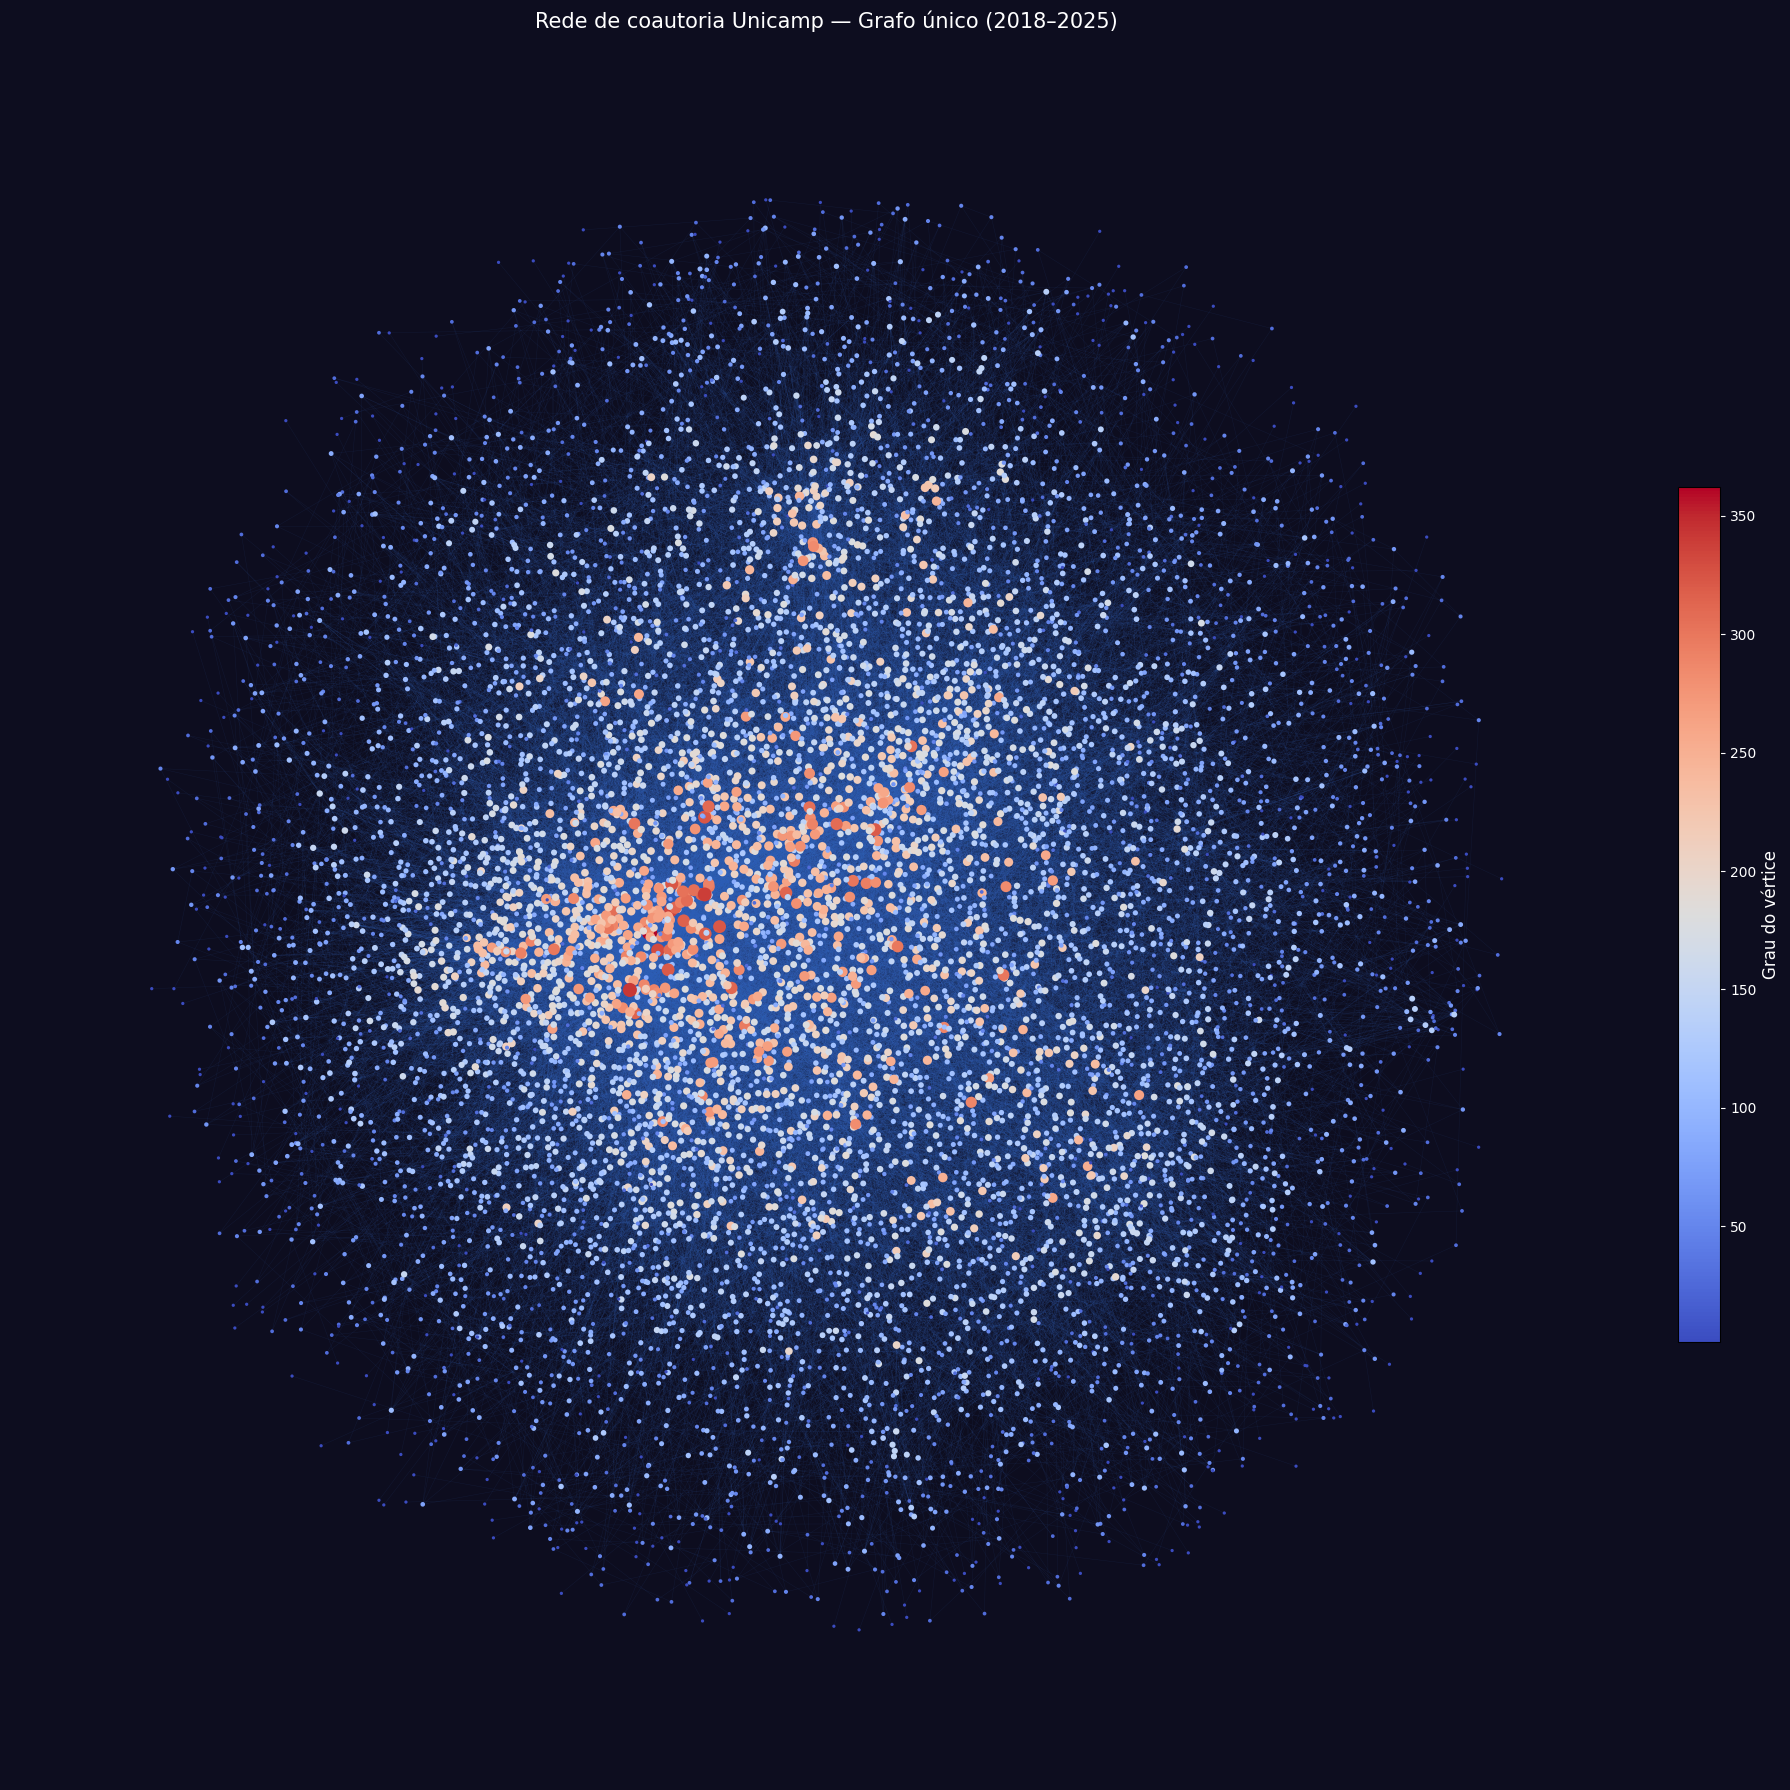

In [21]:
visualizar_grafo(
    nome_arquivo = "grafo_unico.graphml",
    titulo       = "Rede de coautoria Unicamp — Grafo único (2018–2025)",
    nome_imagem  = "img_grafo_unico.png"
)

## 2. Métricas dos grafos

### 2.1 Arestas ativas por ano

Calculando o total de arestas únicas por ano. Uma aresta é considerada "única", no contexto desse trabalho, quando não está presente em nenhum ano anterior. Assim, é possível assegurar que não haverá vazamento de dados de treino para os conjuntos de validação e teste.

In [22]:
from pathlib import Path
import networkx as nx

GRAPHS_DIR = Path("../data/graphs")

G_full = nx.read_graphml(GRAPHS_DIR / "grafo_unico.graphml")

ANO_INI = 2018
ANO_FIM = 2025
ANOS    = list(range(ANO_INI, ANO_FIM + 1))

total = 0
print(f"{'Ano':<8} {'Novas arestas':>14}  {'Split'}")
print("-" * 40)
for ano in ANOS:
    idx           = ano - ANO_INI
    mask_ano      = 1 << idx
    mask_anterior = mask_ano - 1
    count = sum(1 for _, _, d in G_full.edges(data=True)
                if (int(d['anos_ativos']) & mask_ano)
                and not (int(d['anos_ativos']) & mask_anterior))
    total += count
    split = "treino" if ano <= 2023 else ("validação" if ano == 2024 else "teste")
    print(f"{ano:<8} {count:>14,}  {split}")

print("-" * 40)
print(f"{'Total':<8} {total:>14,}")

Ano       Novas arestas  Split
----------------------------------------
2018             12,543  treino
2019             10,015  treino
2020             10,017  treino
2021              9,776  treino
2022              8,851  treino
2023              6,533  treino
2024              3,142  validação
2025              2,423  teste
----------------------------------------
Total            63,300


### 2.2 Tamanho do grafo: vértices, arestas e grau médio

Extração de propriedades básicas do grafo

In [23]:
G_full = nx.read_graphml(GRAPHS_DIR / "grafo_unico.graphml")

n       = G_full.number_of_nodes()
m       = G_full.number_of_edges()
avg_deg = 2 * m / n if n > 0 else 0

metricas = {
    "Grafo único (2018–2025)": {"G": G_full, "n": n, "m": m, "avg_deg": avg_deg}
}

print(f"{'Grafo':<28} {'Vértices':>10} {'Arestas':>10} {'Grau médio':>12}")
print("-" * 64)
for nome, info in metricas.items():
    print(f"{nome:<28} {info['n']:>10,} {info['m']:>10,} {info['avg_deg']:>12.4f}")

Grafo                          Vértices    Arestas   Grau médio
----------------------------------------------------------------
Grafo único (2018–2025)           9,154     63,300      13.8300


### 2.3 Distribuição dos graus

Obtendo a distribuição das colaborações (arestas) dos autores presentes no grafo. Ambos os eixos estão em escala logarítmica para otimizar a visualização.

Salvo em: images/dist_graus_grafo_único_2018-2025.png


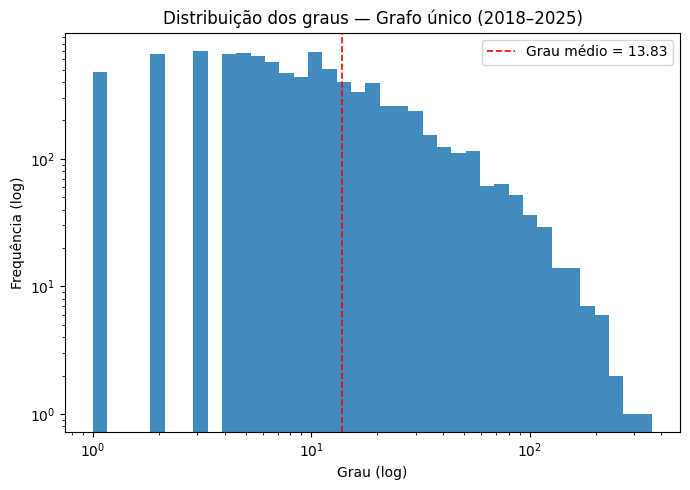

In [24]:
def plotar_distribuicao_graus(nome, info, salvar_em=None):
    fig, ax = plt.subplots(figsize=(7, 5))

    graus    = [d for _, d in info["G"].degree()]
    min_grau = max(1, min(graus))
    bins     = np.logspace(np.log10(min_grau), np.log10(max(graus) + 1), 40)
    ax.hist(graus, bins=bins, alpha=0.85, edgecolor="none")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Distribuição dos graus — {nome}")
    ax.set_xlabel("Grau (log)")
    ax.set_ylabel("Frequência (log)")
    ax.axvline(info["avg_deg"], color="red", linestyle="--", linewidth=1.2,
               label=f"Grau médio = {info['avg_deg']:.2f}")
    ax.legend()

    plt.tight_layout()
    if salvar_em is not None:
        plt.savefig(salvar_em, dpi=150, bbox_inches="tight")
        print(f"Salvo em: {salvar_em}")
    plt.show()


for nome, info in metricas.items():
    nome_arquivo = nome.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("–", "-")
    plotar_distribuicao_graus(nome, info, salvar_em=IMAGES_DIR / f"dist_graus_{nome_arquivo}.png")

### 2.4 Componentes conexas

In [25]:
print(f"{'Grafo':<22} {'Direcionado':>12} {'Componentes':>13} {'Tipo':>30} {'Maior comp. (%)':>16}")
print("-" * 97)
for nome, info in metricas.items():
    G = info["G"]
    is_directed = G.is_directed()

    if is_directed:
        componentes = list(nx.strongly_connected_components(G))
        tipo = "Fortemente conexas (SCC)"
    else:
        componentes = list(nx.connected_components(G))
        tipo = "Conexas (CC)"

    n_comp = len(componentes)
    maior  = max(len(c) for c in componentes)
    pct    = 100 * maior / info["n"] if info["n"] > 0 else 0

    print(f"{nome:<22} {'Sim' if is_directed else 'Não':>12} {n_comp:>13,} {tipo:>30} {pct:>15.2f}%")

Grafo                   Direcionado   Componentes                           Tipo  Maior comp. (%)
-------------------------------------------------------------------------------------------------
Grafo único (2018–2025)          Não             1                   Conexas (CC)          100.00%


### 2.5 Distribuição dos tamanhos das componentes

In [26]:
def plotar_distribuicao_componentes(nome, info, salvar_em=None):
    G = info["G"]

    if G.is_directed():
        componentes = list(nx.strongly_connected_components(G))
        tipo_comp = "SCC"
    else:
        componentes = list(nx.connected_components(G))
        tipo_comp = "CC"

    n_comp = len(componentes)
    if n_comp <= 1:
        print(f"{nome}: apenas {n_comp} componente — distribuição omitida.")
        return

    tamanhos = sorted([len(c) for c in componentes])
    contagem = {}
    for t in tamanhos:
        contagem[t] = contagem.get(t, 0) + 1

    ks     = list(contagem.keys())
    counts = list(contagem.values())

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(ks, counts, s=40, zorder=3)
    ax.vlines(ks, 0, counts, alpha=0.4, linewidth=1)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Tamanho das componentes ({tipo_comp}) — {nome}")
    ax.set_xlabel("Tamanho da componente k (log)")
    ax.set_ylabel("Número de componentes (log)")

    maior = max(tamanhos)
    ax.axvline(maior, color="red", linestyle="--", linewidth=1.2,
               label=f"Maior componente: {maior:,} vértices")
    ax.legend()

    plt.tight_layout()
    if salvar_em is not None:
        plt.savefig(salvar_em, dpi=150, bbox_inches="tight")
        print(f"Salvo em: {salvar_em}")
    plt.show()


for nome, info in metricas.items():
    nome_arquivo = nome.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("–", "-")
    plotar_distribuicao_componentes(nome, info, salvar_em=IMAGES_DIR / f"dist_componentes_{nome_arquivo}.png")

Grafo único (2018–2025): apenas 1 componente — distribuição omitida.
